# Testes de hipóteses paramétricos

Os métodos paramétricos são aplicados para dados quantitativos e exigem suposições fortes para sua validação, incluindo:

- as observações devem ser independentes;
- a amostra deve ser retirada de populações com determinada distribuição, geralmente a normal;
- as populações devem ter variâncias iguais para testes de comparação de duas médias populacionais emparelhadas ou $k$ médias populacionais ($k \ge 3$);
- as variáveis em estudo devem ser medidas em escala intervalar ou de razão, do modo que seja possível utilizar operações aritméticas sobre os respectivos valores.

## Testes sobre uma média populacional ($\mu$) a partir de uma amostra aleatória

O objetivo é testar se uma média populacional assume ou não determinado valor

### Teste z quando o desvio-padrão populacional ($\sigma$) for conhecido e a distribuição for normal

Esse teste é aplicado quando uma amostra aleatória de tamanho $n$ for extraída de uma população com distribuição normal com média ($\mu$) desconhecida e desvio-padrão ($\sigma$) conhecido. 

Para um teste bilateral, as hipóteses são:

- $H_0$: a amostra provém de uma população com determinada média ($\mu = \mu_0$)
- $H_1$: contesta a hipótese nula ($\mu \neq \mu_0$)

A estatística do teste refere-se à média amostral ($\bar{X}$), tal que:

$$
Z_{cal} = \frac{\bar{X} - \mu_0}{\sigma_{\bar{X}}} \quad \text{ em que } \sigma_{\bar{X}} = \frac{\sigma}{\sqrt{n}}
$$

O SciPy não tem uma função específica para este teste. Mas podemos criar.


Exemplo: Um fabricante de caixas de papelão deseja verificar se a quantidade de papelão que está sendo utilizada em cada caixa está de acodo com seu padrão histórico, pois existem indícios de que o consumo aumentou. Historicamente, são utilizados, em média 100 g de papelão em cada caixa e o desvio padrão é de 12 g. Coletou-se uma amostra (base a seguir) para verificar se a média atual é **maior** do que a média histórica.

$H_1$: $\mu > 100$

In [14]:
import pandas as pd

BASE_PAPELAO = "../dados/papelao.csv"

df_papelao = pd.read_csv(BASE_PAPELAO)

df_papelao.head()

,massa
0,102
1,107
2,100
3,101
4,106


In [15]:
df_papelao.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   massa   40 non-null     int64
dtypes: int64(1)
memory usage: 452.0 bytes


In [16]:
df_papelao.describe()

,massa
count,40.000000
mean,104.075000
std,4.293033
min,97.000000
25%,100.000000
50%,103.500000
75%,107.000000
max,115.000000


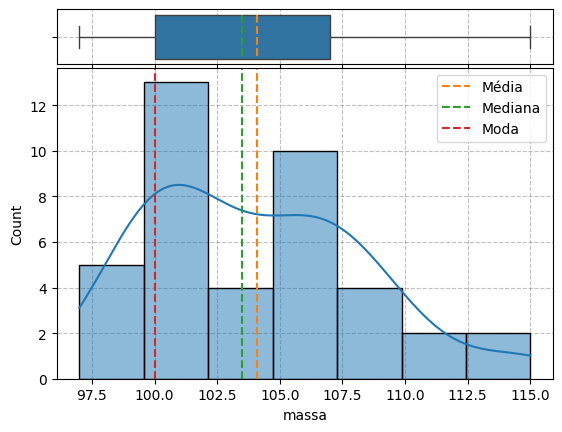

In [17]:
from auxiliares import composicao_boxplot

composicao_boxplot(df_papelao, "massa")

In [18]:
from auxiliares import analise_shapiro

analise_shapiro(df_papelao)

Teste de Shapiro-Wilk
estatistica=0.946
massa segue uma distribuição normal (valor p: pvalue=0.057)


In [28]:
import numpy as np
from scipy.stats import norm 

from collections import namedtuple

def test_z(dados, media_pop, desvio_pop):
    n = len(dados)
    media_amostral = np.mean(dados)
    desvio_amostral = desvio_pop / np.sqrt(n)
    z = (media_amostral - media_pop) / desvio_amostral
    valor_p = 1 - norm.cdf(z)
    TesteZ = namedtuple("TesteZ", ["estatistica", "valor_p"])
    return TesteZ(z, valor_p)

In [29]:
resultado = test_z(df_papelao["massa"], 100, 12)

In [30]:
resultado

TesteZ(estatistica=np.float64(2.1477135775310257), valor_p=np.float64(0.01586825804401104))

In [31]:
resultado.estatistica

np.float64(2.1477135775310257)

In [32]:
resultado.valor_p

np.float64(0.01586825804401104)

In [22]:
test_z(df_papelao["massa"], 100, 12)

(np.float64(2.1477135775310257), np.float64(0.01586825804401104))

In [23]:
norm.cdf(2.1477135775310257)

np.float64(0.984131741955989)

In [24]:
1 - norm.cdf(2.1477135775310257)

np.float64(0.01586825804401104)

Como o valor p é menor que 0.05 a hipotese nula é rejeitada e ha maior consumo de papelão no processo

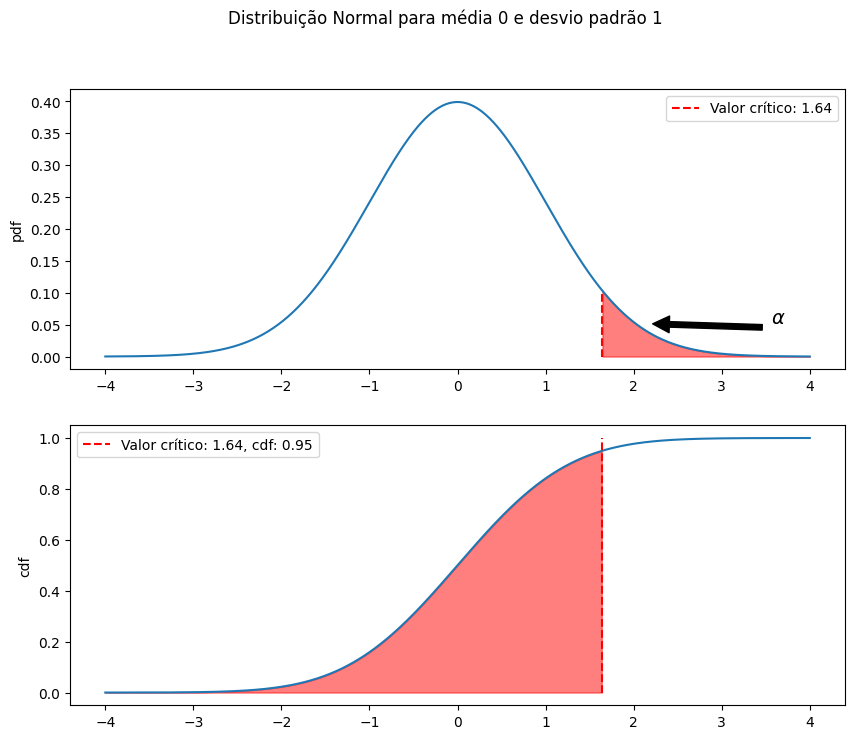

In [27]:
from graficos import plot_normal

plot_normal(0, 1, 0.05, "direita")